In [ ]:
import pandas as pd
df = pd.read_csv("/content/twitter_multi_class_sentiment.csv")
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        16000 non-null  object
 1   label       16000 non-null  int64 
 2   label_name  16000 non-null  object
dtypes: int64(1), object(2)
memory usage: 375.1+ KB


In [ ]:
df.isnull().sum().sum()

0

In [ ]:
df['label'].value_counts()

,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


# Dataset Analysis

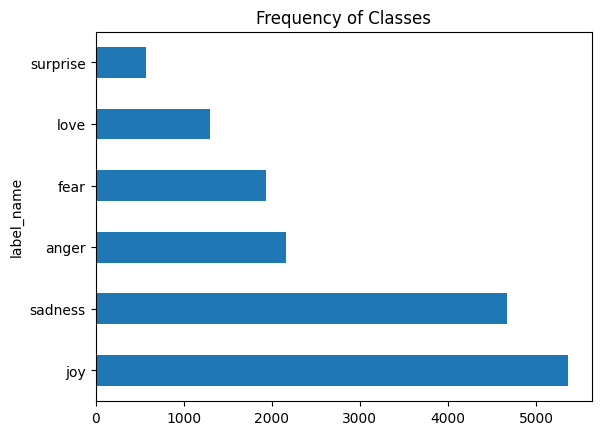

In [ ]:
import matplotlib.pyplot as plt
label_counts = df['label_name'].value_counts()
label_counts.plot.barh()
plt.title("Frequency of Classes")
plt.show()

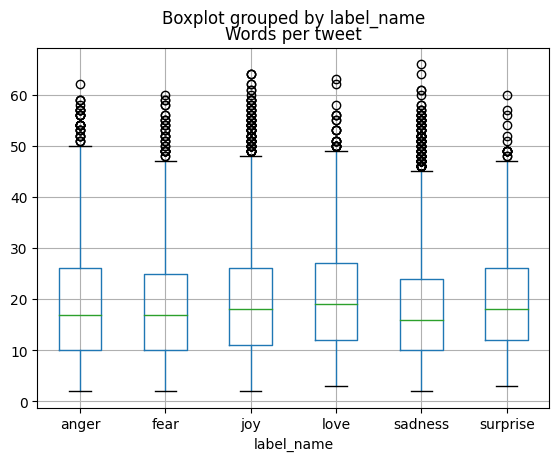

In [ ]:
# In tweets, what the length of words used
df['Words per tweet'] = df['text'].str.split().apply(len)
df.boxplot("Words per tweet", by='label_name')
plt.show()

In [ ]:
df['text'].str.split().apply(len)

,text
0,4
1,21
2,10
3,18
4,4
...,...
15995,24
15996,20
15997,6
15998,14


# Text to Tokens conversion

1) Transformers models like BERT cannot receive raw strings as input, instead they assume the text has been tokenized and encoded as numerical vector

2) Tokenization is the step of breaking down a string into the atomic unit in the model

In [ ]:
from transformers import AutoTokenizer
model_ckpt = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
text = "I love machine learning! Tokenization is awesome!"
encoded_text = tokenizer(text)
print(encoded_text)

{'input_ids': [101, 1045, 2293, 3698, 4083, 999, 19204, 3989, 2003, 12476, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [ ]:
tokenizer.vocab

{'lacy': 19959,
 '##hol': 14854,
 'verses': 11086,
 'pinnacle': 26007,
 '##ख': 29852,
 'blockbuster': 27858,
 'moves': 5829,
 '##ctions': 22014,
 'satisfying': 17087,
 'paul': 2703,
 '##ses': 8583,
 'sydney': 3994,
 '##⁵': 30074,
 'shuttle': 10382,
 'unanimous': 13604,
 'downtown': 5116,
 'mistakes': 12051,
 'maddie': 17805,
 '##ens': 6132,
 'knoxville': 20021,
 '##haling': 23896,
 'americana': 25988,
 'stationary': 17337,
 'hello': 7592,
 'eurasian': 23399,
 'helium': 22764,
 'investors': 9387,
 'dave': 4913,
 'wooded': 17172,
 'karnataka': 12092,
 'southern': 2670,
 'corruption': 7897,
 '45': 3429,
 'variants': 10176,
 'tt': 23746,
 '##lan': 5802,
 'assassinated': 16370,
 'ends': 4515,
 'jokes': 13198,
 'stain': 21101,
 '⅔': 1582,
 '##cence': 29320,
 'risky': 19188,
 'cash': 5356,
 '##yah': 17560,
 '1766': 21410,
 '##名': 30321,
 'invincible': 25018,
 'munster': 11348,
 '[unused720]': 725,
 'muted': 22124,
 'silvia': 27827,
 'develops': 11791,
 'artistic': 6018,
 'uefa': 6663,
 '##uke

In [ ]:
len(tokenizer.vocab)

30522

In [ ]:
tokenizer.model_max_length

512

# Data Loader and Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.3, stratify=df['label_name'])
test, validation = train_test_split(test, test_size=1/3, stratify=test['label_name'])
train.shape, test.shape, validation.shape

((11200, 4), (3200, 4), (1600, 4))

In [ ]:
#!pip install datasets

In [ ]:
from datasets import Dataset, DatasetDict

dataset = DatasetDict({"train" :Dataset.from_pandas(train, preserve_index=False),
                       "test":Dataset.from_pandas(test, preserve_index=False),
                       "validation":Dataset.from_pandas(validation,preserve_index=False)})
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'Words per tweet'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'Words per tweet'],
        num_rows: 3200
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'Words per tweet'],
        num_rows: 1600
    })
})

In [ ]:
dataset['train'][0], dataset['train'][1]

({'text': 'im already feeling very loved today and its not even noon',
  'label': 2,
  'label_name': 'love',
  'Words per tweet': 11},
 {'text': 'i feel sorry for those that can t eat mangoes amp grateful i can',
  'label': 0,
  'label_name': 'sadness',
  'Words per tweet': 14})

In [ ]:
dataset['train'][10], dataset['train'][20]

({'text': 'ive been a busy girl but it has been a very good type of busy and im feeling really happy about things right now and i am loving my new start in glasgow',
  'label': 1,
  'label_name': 'joy',
  'Words per tweet': 33},
 {'text': 'i just feel pathetic for this world',
  'label': 0,
  'label_name': 'sadness',
  'Words per tweet': 7})

In [ ]:
#!pip install transformers
from transformers import AutoTokenizer

# Example: Replace 'bert-base-uncased' with your desired model
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def tokenize(batch):
    # Use the tokenizer from Transformers
    temp = tokenizer(batch['text'], padding=True, truncation=True)
    return temp

print(tokenize(dataset['train'][:2]))

{'input_ids': [[101, 10047, 2525, 3110, 2200, 3866, 2651, 1998, 2049, 2025, 2130, 11501, 102, 0, 0, 0, 0], [101, 1045, 2514, 3374, 2005, 2216, 2008, 2064, 1056, 4521, 24792, 2229, 23713, 8794, 1045, 2064, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
emotion_encoded = dataset.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

In [ ]:
label2id = {x['label_name']:x['label'] for x in dataset['train']}
id2label = {v:k for k,v in label2id.items()}
label2id, id2label

({'love': 2, 'sadness': 0, 'anger': 3, 'joy': 1, 'surprise': 5, 'fear': 4},
 {2: 'love', 0: 'sadness', 3: 'anger', 1: 'joy', 5: 'surprise', 4: 'fear'})

# Building BERT MODEL by using transformeres automodel

In [ ]:
from transformers import AutoModel
import torch
model = AutoModel.from_pretrained(model_ckpt)

In [ ]:
model.config.id2label
model.config

BertConfig {
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.44.2",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

In [ ]:
from transformers import TrainingArguments

batch_size= 64
training_dir='bert_base_train_dir'
training_arg = TrainingArguments(output_dir=training_dir,overwrite_output_dir=True,
                                 num_train_epochs=2, learning_rate =  2e-5,
                                 per_device_eval_batch_size=batch_size,
                                 per_device_train_batch_size=batch_size,
                                 weight_decay=0.01, evaluation_strategy="epoch")

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
!pip install evaluate

In [ ]:
import evaluate
import numpy as np
accuracy = evaluate.load("accuracy")

def compute_metrics_evaluate(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score


def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {"accuracy": acc, "f1":f1}

# Build Evaluation metrics with BERT and Trainer

In [ ]:
from transformers import Trainer


trainer = Trainer(model = model, args=training_arg,
                  compute_metrics=compute_metrics,
                  train_dataset = emotion_encoded['train'],
                  eval_dataset = emotion_encoded['validation'],
                  tokenizer = tokenizer)

In [ ]:
from transformers import Trainer, AutoModelForSequenceClassification # import the correct model class

# replace model with AutoModelForSequenceClassification
trainer = Trainer(model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased",
                                                                             num_labels=len(label2id)),
                  args=training_arg,
                  compute_metrics=compute_metrics,
                  train_dataset = emotion_encoded['train'],
                  eval_dataset = emotion_encoded['validation'],
                  tokenizer = tokenizer)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.477806,0.850625,0.844361
2,No log,0.298245,0.902500,0.902610


TrainOutput(global_step=350, training_loss=0.6875924682617187, metrics={'train_runtime': 351.1186, 'train_samples_per_second': 63.796, 'train_steps_per_second': 0.997, 'total_flos': 1001502421516800.0, 'train_loss': 0.6875924682617187, 'epoch': 2.0})

In [ ]:
# Model Evaluation with Test

preds_output = trainer.predict(emotion_encoded['test'])
preds_output.metrics

{'test_loss': 0.30076849460601807,
 'test_accuracy': 0.900625,
 'test_f1': 0.9006957492016257,
 'test_runtime': 14.5988,
 'test_samples_per_second': 219.197,
 'test_steps_per_second': 3.425}

In [ ]:
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = emotion_encoded['test']['label']

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94       933
           1       0.94      0.90      0.92      1072
           2       0.74      0.81      0.77       261
           3       0.89      0.92      0.91       432
           4       0.86      0.88      0.87       387
           5       0.83      0.69      0.75       115

    accuracy                           0.90      3200
   macro avg       0.87      0.86      0.86      3200
weighted avg       0.90      0.90      0.90      3200



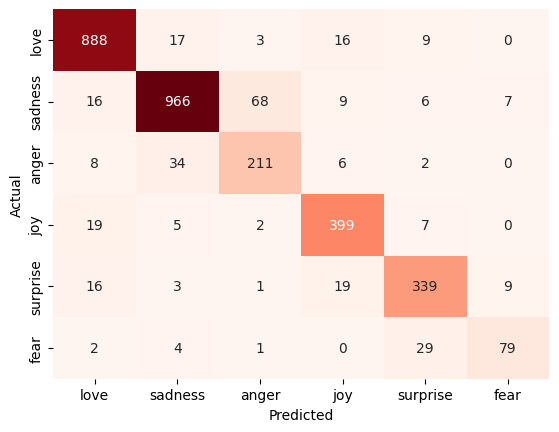

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, xticklabels = label2id.keys(), yticklabels = label2id.keys(),
            fmt='d', cbar=False, cmap = 'Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Build Prediction Function and Store Model



In [ ]:
# Use a BertForSequenceClassification model for sequence classification tasks.
# Make sure to replace 'num_labels' with the number of classes in your classification task.
!pip install transformers

In [ ]:
from transformers import BertForSequenceClassification, BertTokenizer

# Replace 'bert-base-uncased' with the desired pre-trained model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=6)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

text = " I am super happy today. I got it done. Finally!!"

input_encoded = tokenizer(text, return_tensors='pt')

with torch.no_grad():
  output = model(**input_encoded)

# Access the logits from the output
logits = output.logits

pred = torch.argmax(logits, dim=1).item()
id2label[pred]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


'sadness'

In [ ]:
logits

tensor([[ 0.0080,  0.9037,  0.2134, -0.1593,  0.8707,  0.2879]])

In [ ]:
trainer.save_model('bert-base-uncased-sentiment-model')

In [ ]:
from transformers import pipeline
classifier = pipeline("text-classification", model="bert-base-uncased-sentiment-model")
classifier(['Hello, how are you?', 'love you','I am highly disappointed with your performance',
            "I will kill you","I am very worry about you","I can't believe this just happened!",
            "Are you serious? That’s incredible!",
            "an octopus has three hearts and blue blood",
            "i have seen heard and read over the past couple of days i am left feeling impressed by more than a few companies"])

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


[{'label': 'LABEL_1', 'score': 0.8998863101005554},
 {'label': 'LABEL_2', 'score': 0.700250506401062},
 {'label': 'LABEL_0', 'score': 0.9667016863822937},
 {'label': 'LABEL_3', 'score': 0.6837227940559387},
 {'label': 'LABEL_4', 'score': 0.3255648910999298},
 {'label': 'LABEL_1', 'score': 0.745566189289093},
 {'label': 'LABEL_1', 'score': 0.8477252721786499},
 {'label': 'LABEL_1', 'score': 0.6660363674163818},
 {'label': 'LABEL_5', 'score': 0.7269494533538818}]